In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\Dell\Documents\DA\customer_purchase_complex.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             50000 non-null  object 
 1   customer_id          50000 non-null  object 
 2   order_date           50000 non-null  object 
 3   product_category     50000 non-null  object 
 4   product_name         49950 non-null  object 
 5   quantity             50000 non-null  int64  
 6   price_per_unit       50000 non-null  float64
 7   payment_method       50000 non-null  object 
 8   delivery_status      50000 non-null  object 
 9   customer_state       50000 non-null  object 
 10  rating               45140 non-null  float64
 11  total_price          50000 non-null  float64
 12  customer_email       47478 non-null  object 
 13  shipping_address     50000 non-null  object 
 14  coupon_code          24919 non-null  object 
 15  referral_source      33405 non-null 

In [4]:
df.isnull().sum().sort_values(ascending=False)

return_reason          40711
delivery_date          37483
customer_age           25153
coupon_code            25081
referral_source        16595
product_rating          5116
rating                  4860
customer_email          2522
product_name              50
quantity                   0
order_id                   0
product_category           0
order_date                 0
customer_id                0
shipping_address           0
total_price                0
delivery_status            0
customer_state             0
payment_method             0
price_per_unit             0
loyalty_score              0
product_description        0
dtype: int64

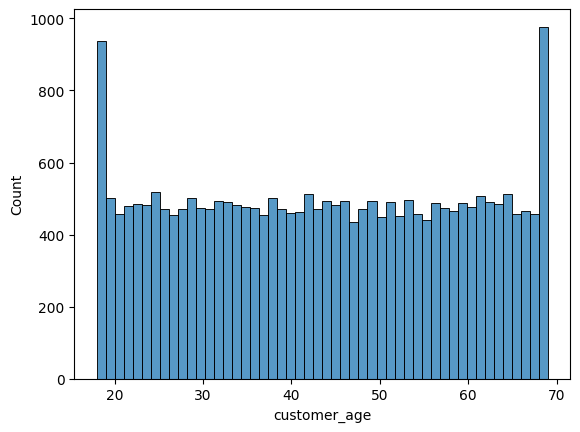

In [5]:
sns.histplot(df['customer_age'], bins=50)
plt.show()

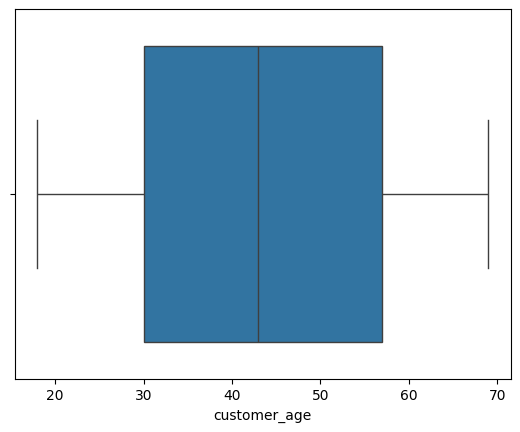

In [6]:
sns.boxplot(x=df['customer_age'])
plt.show()

In [7]:
df['customer_age'].isna().sum()
df['customer_age'].isna().mean()*100

np.float64(50.306)

In [8]:
df['customer_age'].describe()

count    24847.000000
mean        43.486497
std         15.028505
min         18.000000
25%         30.000000
50%         43.000000
75%         57.000000
max         69.000000
Name: customer_age, dtype: float64

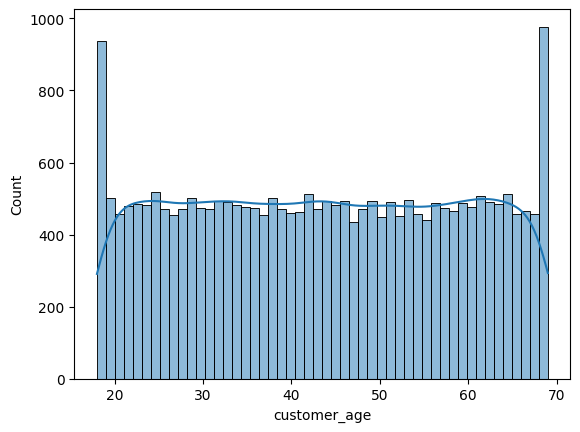

In [9]:
sns.histplot(df['customer_age'], bins=50, kde=True)
plt.show()

In [11]:
#If the data is normally distributed and has no outliers, mean imputation is appropriate. 
# However, age data is often skewed in real-world datasets, 
# so median is generally preferred because it is more robust to outliers.
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())

In [12]:
df['customer_age'].isna().sum()

np.int64(0)

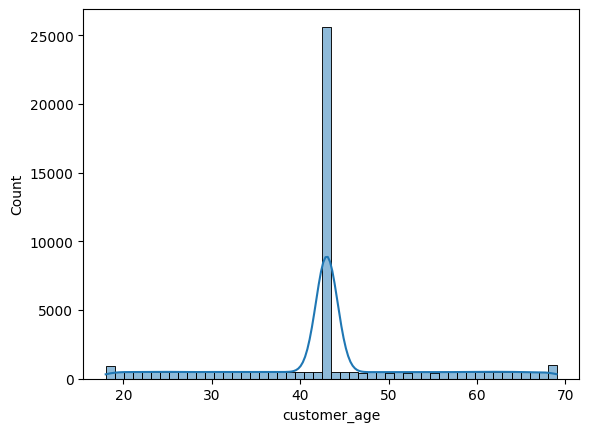

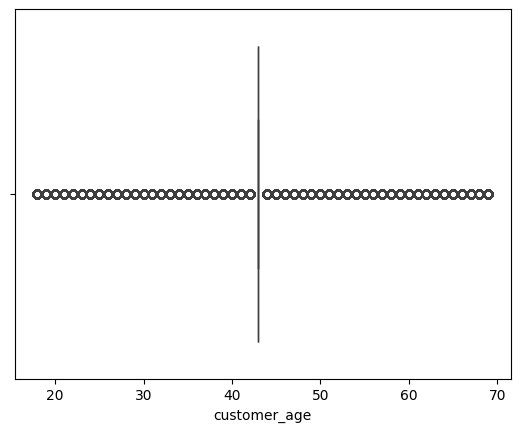

In [13]:
sns.histplot(df['customer_age'], bins=50, kde=True)
plt.show()

sns.boxplot(x=df['customer_age'])
plt.show()

In [14]:
# The spike occurs because around 50% of the values in the customer_age column were missing, 
# and I used median imputation to fill them. Since all missing values were replaced with the same number (the median),
# it created a large concentration of observations at that value, which appears as a spike in the histogram.

# This is a common side effect when the missing percentage is very high. 
# Median imputation preserves the central tendency but can distort the distribution by introducing an artificial peak.

In [15]:
# delivery_date
# Convert to datetime
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

# Add a flag for missing deliveries
df['delivery_missing'] = df['delivery_date'].isnull()

In [16]:
# return_reason
df['return_reason'] = df['return_reason'].fillna('Not Returned')

In [17]:
# filling null values in product_name column
df['product_name'] = df['product_name'].fillna('Unknown Product')

In [18]:
# filling null values in customer_email column
df['customer_email'] = df['customer_email'].fillna('no_email')

In [19]:
# filling null values in rating and product_rating column
# Fill missing customer rating with the mean
df['rating'] = df['rating'].fillna(df['rating'].mean())

# Fill missing product rating with the mean
df['product_rating'] = df['product_rating'].fillna(df['product_rating'].mean())


In [20]:
# filling null values in referral_source column
df['referral_source'] = df['referral_source'].fillna('Untracked')

In [21]:
# filling null values in coupon_code column
df['coupon_code'] = df['coupon_code'].fillna('NO_COUPON')

In [22]:
# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

In [23]:
df.isnull().sum().sort_values(ascending=False)

delivery_date          37483
customer_id                0
order_id                   0
product_category           0
product_name               0
quantity                   0
order_date                 0
price_per_unit             0
payment_method             0
customer_state             0
delivery_status            0
total_price                0
customer_email             0
shipping_address           0
rating                     0
coupon_code                0
referral_source            0
product_rating             0
return_reason              0
customer_age               0
loyalty_score              0
product_description        0
delivery_missing           0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             50000 non-null  object        
 1   customer_id          50000 non-null  object        
 2   order_date           50000 non-null  datetime64[ns]
 3   product_category     50000 non-null  object        
 4   product_name         50000 non-null  object        
 5   quantity             50000 non-null  int64         
 6   price_per_unit       50000 non-null  float64       
 7   payment_method       50000 non-null  object        
 8   delivery_status      50000 non-null  object        
 9   customer_state       50000 non-null  object        
 10  rating               50000 non-null  float64       
 11  total_price          50000 non-null  float64       
 12  customer_email       50000 non-null  object        
 13  shipping_address     50000 non-

In [26]:
# standardising column names
df.columns = (
    df.columns
    .str.strip()  # remove leading/trailing spaces
    .str.lower()  # convert to lowercase
    .str.replace(' ', '_')  # replace spaces with underscores
)

In [27]:
df.describe(include='object')

,order_id,customer_id,product_category,product_name,payment_method,delivery_status,customer_state,customer_email,shipping_address,coupon_code,referral_source,return_reason,product_description
count,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000,50000
unique,50000,8973,6,971,5,4,6,46384,50000,2704,5,4,50000
top,ORD149983,CUST9029,Electronics,Front,Debit Card,Pending,WestBengal,no_email,"69441 Hernandez Island Apt. 626, Lake Ashley, ...",NO_COUPON,Untracked,Not Returned,Word inside water education.
freq,1,16,8408,75,10085,12570,8432,2522,1,25081,16595,40711,1


In [29]:
#Delivery status distribution
df['delivery_status'].value_counts()

#Orders per product category
df['product_category'].value_counts()

#Revenue by category
df.groupby('product_category')['total_price'].sum().sort_values(ascending=False)

#Payment method distribution
df['payment_method'].value_counts()

#State-wise revenue
df.groupby('customer_state')['total_price'].sum()

customer_state
Karnataka      52458750.80
Maharashtra    53530499.39
Tamil Nadu     52448194.87
WestBengal     52923394.00
delhi          53408501.62
gujrat         53130607.58
Name: total_price, dtype: float64

In [30]:
# Revenue across states is relatively balanced, with Maharashtra generating the highest total revenue (~53.5M), 
# followed closely by Delhi and Gujarat. 
# This suggests that the business has a well-distributed customer base across regions without heavy dependence on a single market.

In [31]:
# corder trends over time.
df.groupby(df['order_date'].dt.month)['total_price'].sum()

(df['quantity'] * df['price_per_unit'] - df['total_price']).sum()
# This checks whether:
# total_price = quantity × price_per_unit
# Many real datasets have calculation errors, so analysts always verify this.

np.float64(-1.900275492516812e-10)

In [32]:
# The calculated difference between quantity × price_per_unit and total_price was approximately zero, 
# indicating that the total price values are correctly computed. 
# The tiny difference observed is due to floating-point precision in numerical calculations.

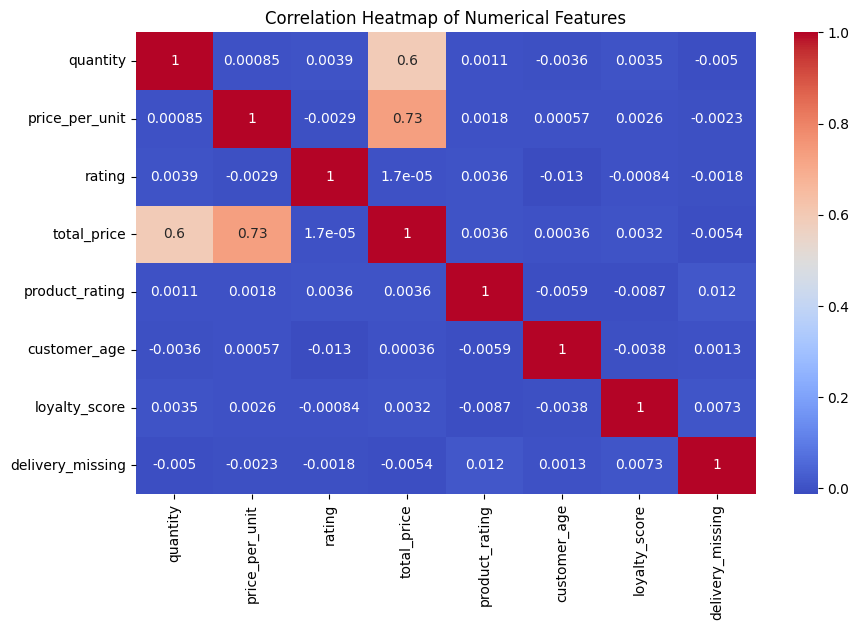

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [34]:
df.corr(numeric_only=True)

,quantity,price_per_unit,rating,total_price,product_rating,customer_age,loyalty_score,delivery_missing
quantity,1.000000,0.000848,0.003926,0.595796,0.001068,-0.003609,0.003511,-0.005029
price_per_unit,0.000848,1.000000,-0.002899,0.733336,0.001754,0.000567,0.002576,-0.002296
rating,0.003926,-0.002899,1.000000,0.000017,0.003612,-0.012867,-0.000839,-0.001823
total_price,0.595796,0.733336,0.000017,1.000000,0.003645,0.000359,0.003169,-0.005389
product_rating,0.001068,0.001754,0.003612,0.003645,1.000000,-0.005925,-0.008741,0.011745
customer_age,-0.003609,0.000567,-0.012867,0.000359,-0.005925,1.000000,-0.003765,0.001273
loyalty_score,0.003511,0.002576,-0.000839,0.003169,-0.008741,-0.003765,1.000000,0.007275
delivery_missing,-0.005029,-0.002296,-0.001823,-0.005389,0.011745,0.001273,0.007275,1.000000


<Axes: xlabel='quantity', ylabel='total_price'>

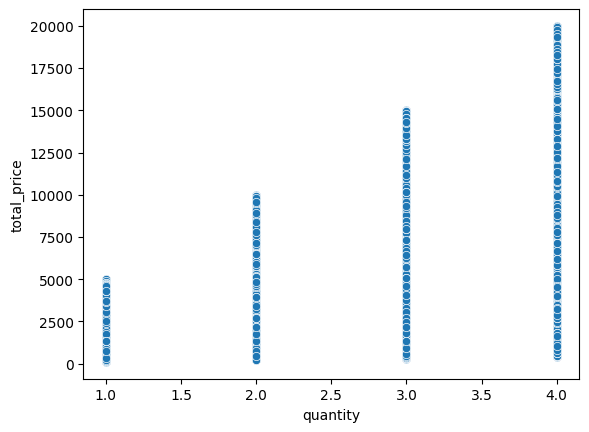

In [35]:
sns.scatterplot(x='quantity', y='total_price', data=df)

<Axes: xlabel='product_category', ylabel='total_price'>

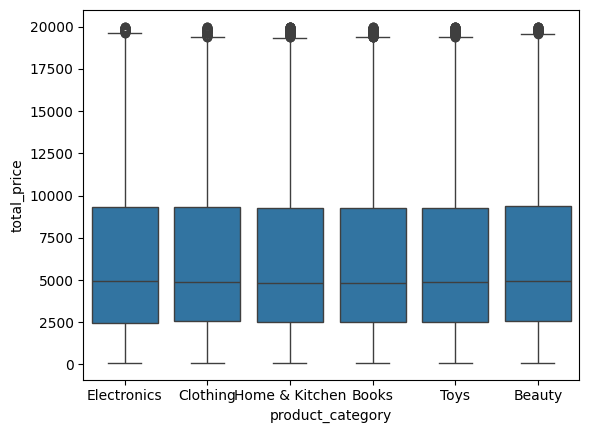

In [36]:
sns.boxplot(x='product_category', y='total_price', data=df)

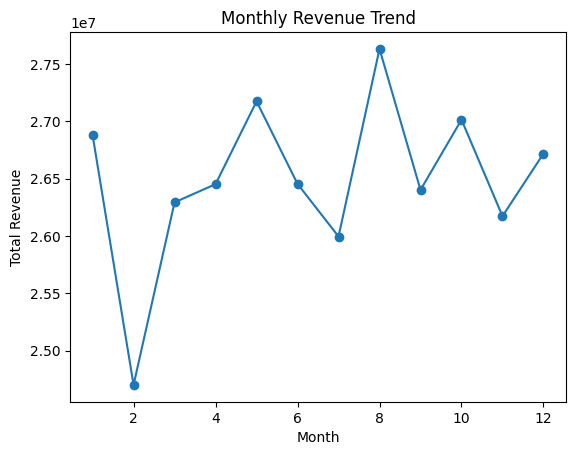

In [37]:
monthly_sales = df.groupby(df['order_date'].dt.month)['total_price'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

## Key Findings
- Dataset shows uniform patterns across most categorical 
  variables, consistent with synthetically generated data
- Total price is strongly driven by quantity and 
  price_per_unit (correlations: 0.6 and 0.73)
- No significant regional variation in payment preferences
  across 6 Indian states
- Delivery status shows no impact on customer rating, 
  suggesting rating data needs further validation

In [1]:
import os
os.getcwd()

'C:\\Users\\Dell'